In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

DATA_PATH = "../data/student_placement_prediction_dataset_2026.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 100000
Columns: 26


In [2]:
df.head()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,hackathons_participated,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,81.707722,57.707166,59.070073,4,1,184,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,63.116715,59.197085,78.976419,0,2,539,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,48.658753,92.104885,80.603331,0,2,568,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,66.376653,83.411798,64.187246,1,1,550,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,61.274985,88.956331,56.163678,1,4,833,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In [3]:
df.tail()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,hackathons_participated,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
99995,99996,21,Male,7.97,Mechanical,Tier 2,0,3,5,71.483407,56.904150,87.245760,43.013761,0,5,495,57.738311,75.471631,0,54.399022,66.446410,Yes,8.0,4.3,Placed,14.54
99996,99997,18,Female,7.79,CSE,Tier 1,1,1,2,78.960574,55.729008,42.767277,62.381626,0,2,958,80.076688,77.286948,1,33.692154,69.025632,Yes,4.4,3.1,Not Placed,0.00
99997,99998,20,Female,6.71,IT,Tier 2,2,4,4,66.691775,48.725390,72.394081,70.888580,0,6,272,70.797752,93.115933,0,64.989215,32.733645,Yes,7.6,2.9,Placed,13.45
99998,99999,19,Female,7.21,CSE,Tier 2,2,3,0,67.214893,79.336599,45.375535,52.091126,0,6,576,68.182555,71.306355,1,72.478779,32.205517,No,4.9,2.8,Not Placed,0.00
99999,100000,22,Female,8.58,ECE,Tier 3,1,3,2,92.146277,89.261932,81.629165,94.963205,0,1,812,77.864288,89.919640,0,48.363818,21.166444,Yes,6.5,2.9,Placed,14.43


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  str    
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  str    
 5   college_tier               100000 non-null  str    
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100000 non-nul

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,100000.0,NaN,NaN,NaN,50000.5,28867.657797,1.0,25000.75,50000.5,75000.25,100000.0
age,100000.0,NaN,NaN,NaN,21.00574,1.999562,18.0,19.0,21.0,23.0,24.0
gender,100000,2,Male,60028,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cgpa,100000.0,NaN,NaN,NaN,7.49689,0.992834,4.5,6.82,7.5,8.18,10.0
branch,100000,6,CSE,34818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
college_tier,100000,3,Tier 2,49955,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internships_count,100000.0,NaN,NaN,NaN,1.50223,1.22528,0.0,1.0,1.0,2.0,8.0
projects_count,100000.0,NaN,NaN,NaN,3.00186,1.731764,0.0,2.0,3.0,4.0,13.0
certifications_count,100000.0,NaN,NaN,NaN,2.00515,1.416553,0.0,1.0,2.0,3.0,11.0
coding_skill_score,100000.0,NaN,NaN,NaN,69.825326,14.694618,20.0,59.807945,70.00625,80.058762,100.0


In [6]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['student_id', 'age', 'cgpa', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'sleep_hours', 'study_hours_per_day', 'salary_package_lpa']

Categorical columns:
['gender', 'branch', 'college_tier', 'volunteer_experience', 'placement_status']


In [7]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

if missing_values.empty:
    print("No missing values found.")
else:
    print(missing_values)

No missing values found.


In [8]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [9]:
unique_student_ids = df["student_id"].nunique()

print(f"Total rows: {len(df)}")
print(f"Unique student IDs: {unique_student_ids}")

if unique_student_ids == len(df):
    print("Every student has a unique ID.")
else:
    print("Duplicate student IDs found.")

Total rows: 100000
Unique student IDs: 100000
Every student has a unique ID.


In [10]:
for column in categorical_columns:
    print(f"\n===== {column} =====")
    print(df[column].value_counts())


===== gender =====
gender
Male      60028
Female    39972
Name: count, dtype: int64

===== branch =====
branch
CSE           34818
IT            19999
ECE           14908
EEE           10177
Mechanical    10077
Civil         10021
Name: count, dtype: int64

===== college_tier =====
college_tier
Tier 2    49955
Tier 3    29884
Tier 1    20161
Name: count, dtype: int64

===== volunteer_experience =====
volunteer_experience
No     59963
Yes    40037
Name: count, dtype: int64

===== placement_status =====
placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64


In [11]:
placement_counts = df["placement_status"].value_counts()

print(placement_counts)

print("\nPlacement percentages:")
print(
    df["placement_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64

Placement percentages:
placement_status
Placed        54.46
Not Placed    45.54
Name: proportion, dtype: float64


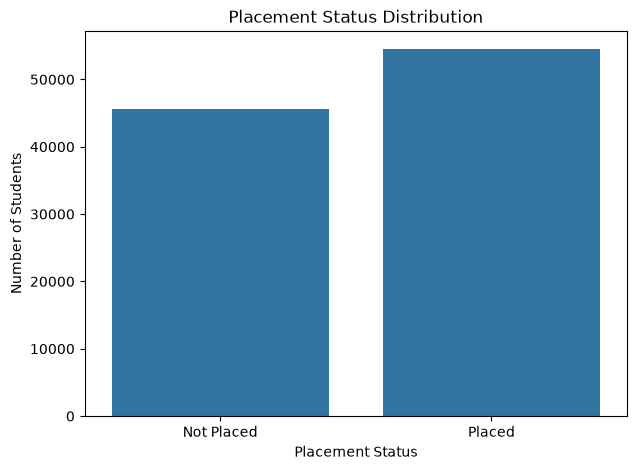

In [12]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="placement_status"
)

plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")

plt.show()

In [13]:
placed_df = df[df["placement_status"] == "Placed"].copy()

print(f"Placed students: {len(placed_df)}")
print(placed_df["salary_package_lpa"].describe())

Placed students: 54459
count    54459.000000
mean        13.316635
std          1.592418
min          7.110000
25%         12.230000
50%         13.300000
75%         14.390000
max         20.440000
Name: salary_package_lpa, dtype: float64


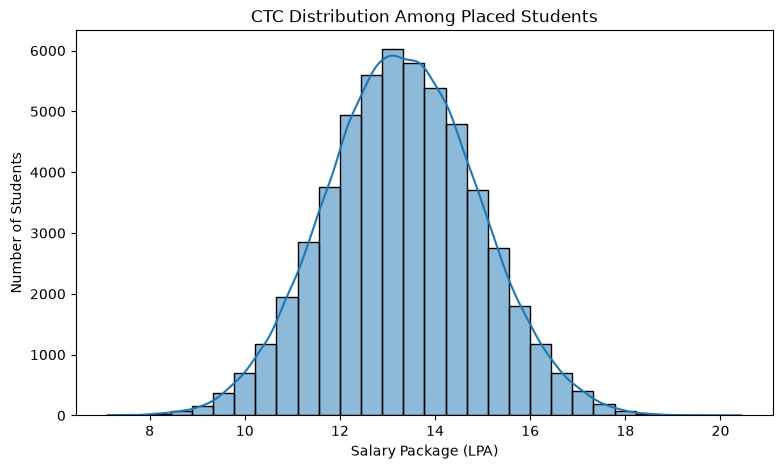

In [14]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=placed_df,
    x="salary_package_lpa",
    bins=30,
    kde=True
)

plt.title("CTC Distribution Among Placed Students")
plt.xlabel("Salary Package (LPA)")
plt.ylabel("Number of Students")

plt.show()

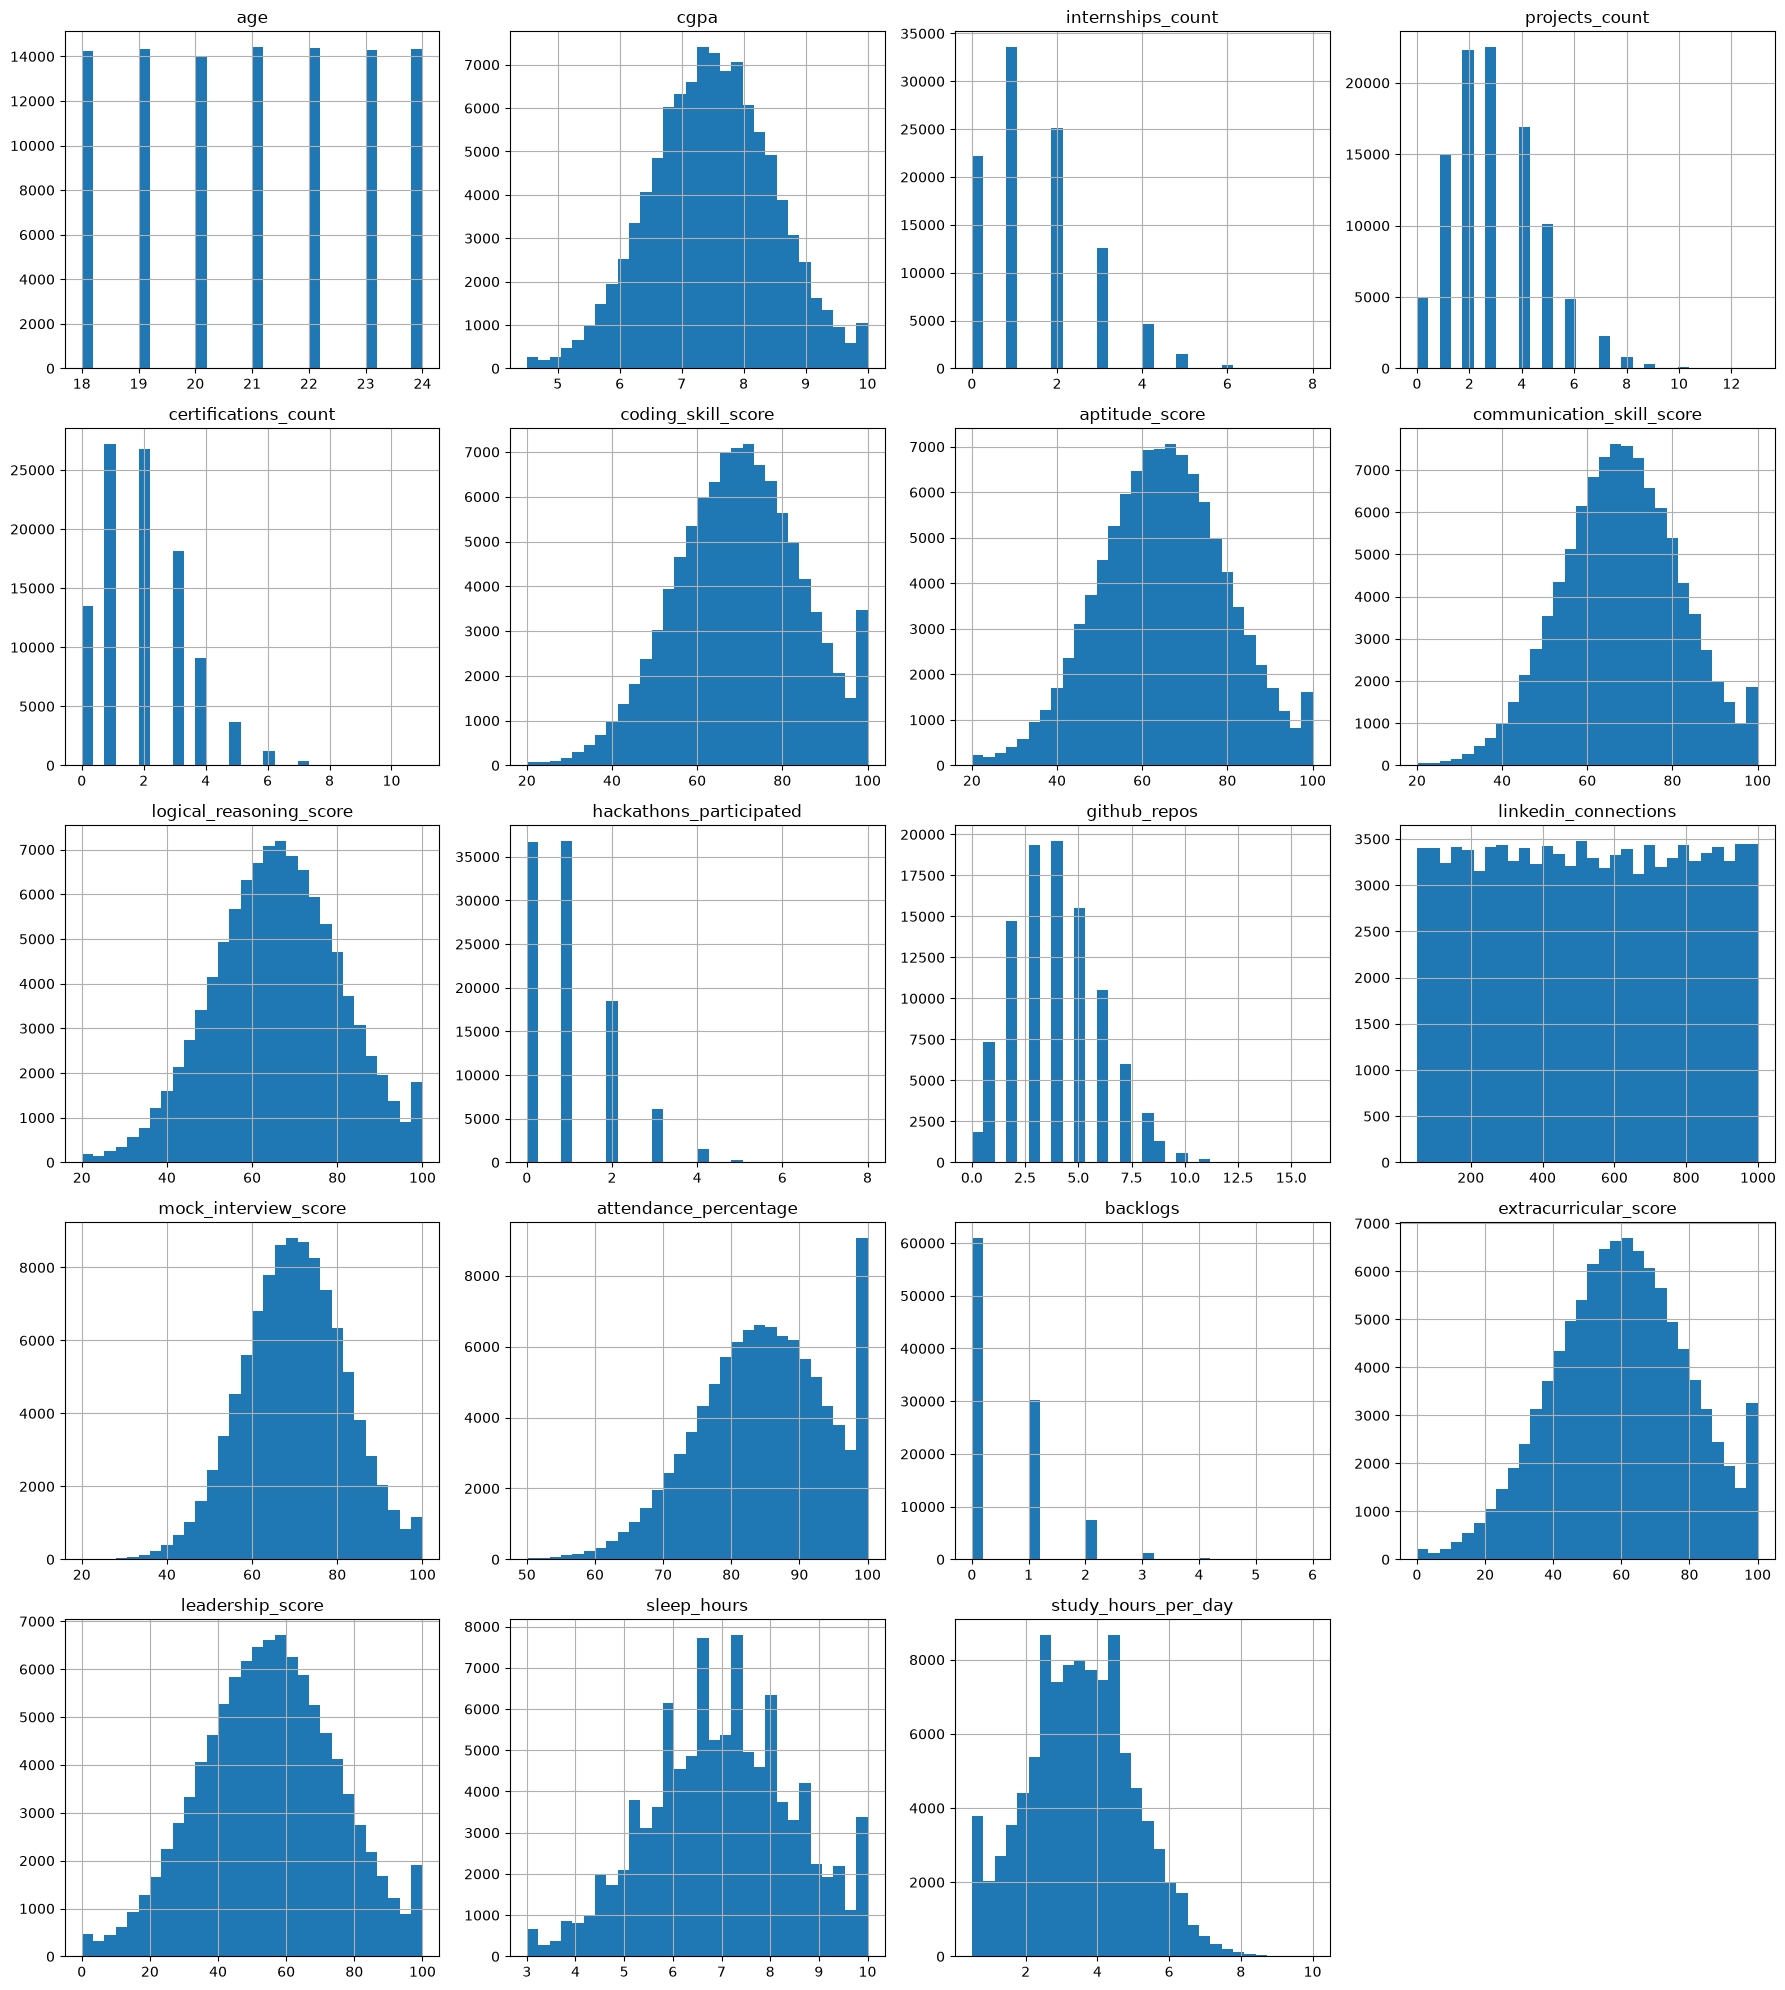

In [15]:
numeric_features = [
    "age",
    "cgpa",
    "internships_count",
    "projects_count",
    "certifications_count",
    "coding_skill_score",
    "aptitude_score",
    "communication_skill_score",
    "logical_reasoning_score",
    "hackathons_participated",
    "github_repos",
    "linkedin_connections",
    "mock_interview_score",
    "attendance_percentage",
    "backlogs",
    "extracurricular_score",
    "leadership_score",
    "sleep_hours",
    "study_hours_per_day"
]

df[numeric_features].hist(
    figsize=(18, 20),
    bins=30
)

plt.tight_layout()
plt.show()

In [16]:
branch_placement = pd.crosstab(
    df["branch"],
    df["placement_status"],
    normalize="index"
) * 100

branch_placement

placement_status,Not Placed,Placed
branch,,
CSE,45.355850,54.644150
Civil,44.825866,55.174134
ECE,45.894822,54.105178
EEE,45.681439,54.318561
IT,45.697285,54.302715
Mechanical,45.916443,54.083557


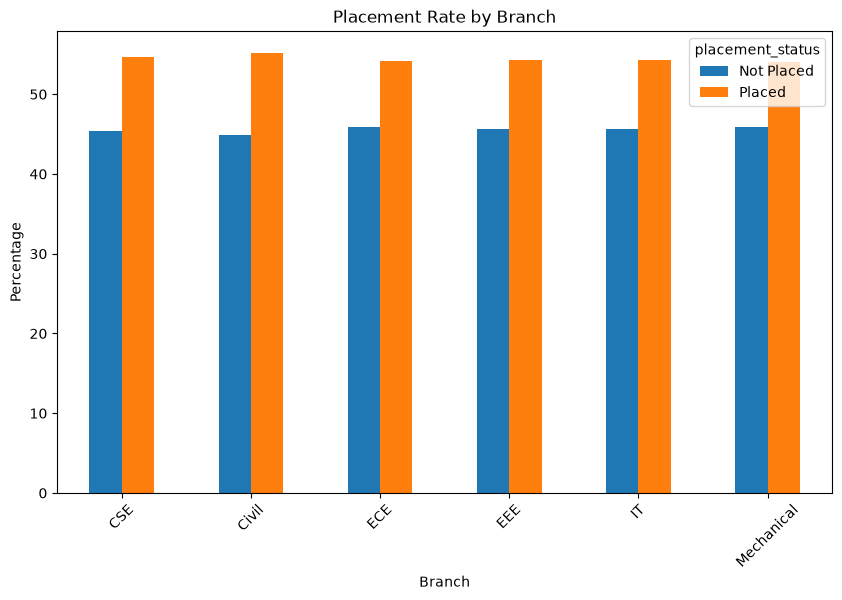

In [17]:
branch_placement.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Placement Rate by Branch")
plt.xlabel("Branch")
plt.ylabel("Percentage")
plt.xticks(rotation=45)

plt.show()

In [18]:
tier_placement = pd.crosstab(
    df["college_tier"],
    df["placement_status"],
    normalize="index"
) * 100

tier_placement

placement_status,Not Placed,Placed
college_tier,,
Tier 1,45.498735,54.501265
Tier 2,45.715144,54.284856
Tier 3,45.278410,54.721590


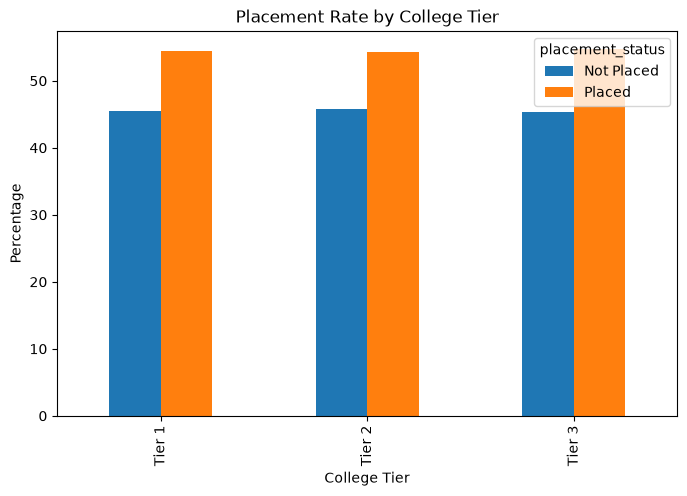

In [19]:
tier_placement.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Placement Rate by College Tier")
plt.xlabel("College Tier")
plt.ylabel("Percentage")

plt.show()

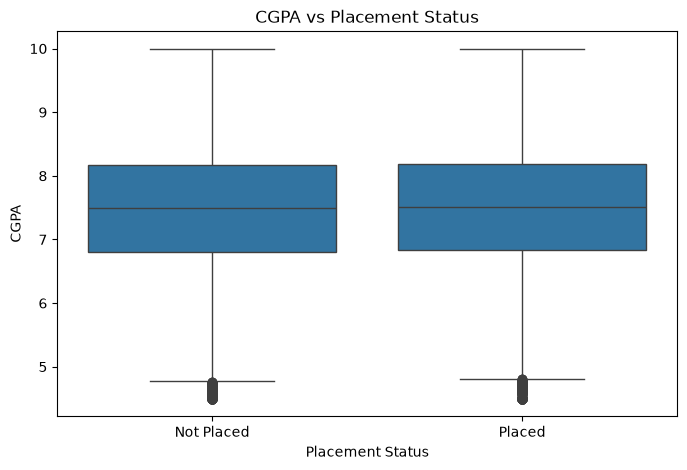

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="placement_status",
    y="cgpa"
)

plt.title("CGPA vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("CGPA")

plt.show()

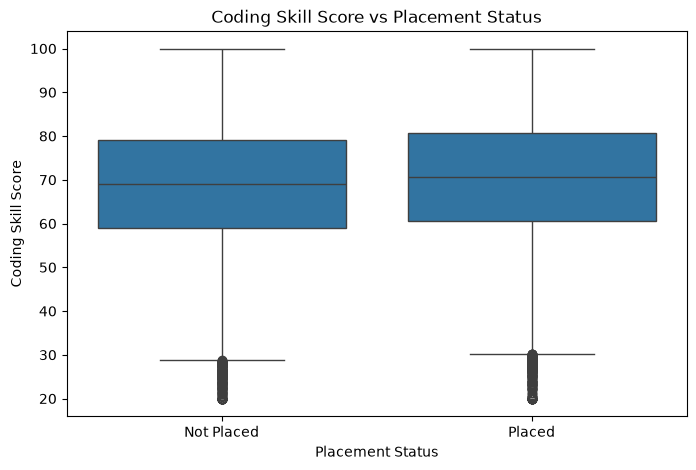

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="placement_status",
    y="coding_skill_score"
)

plt.title("Coding Skill Score vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Coding Skill Score")

plt.show()

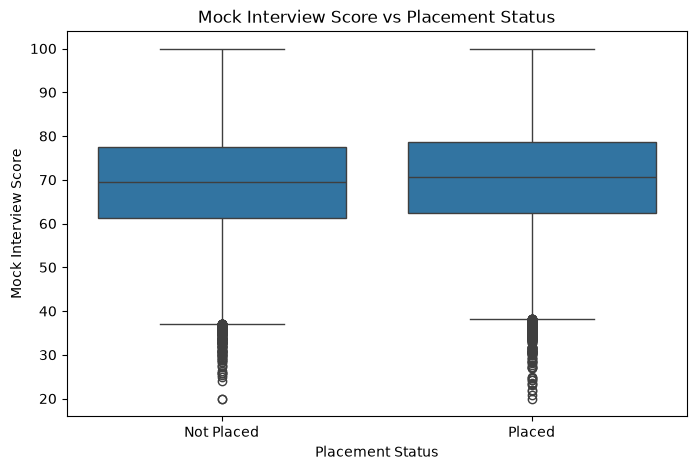

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="placement_status",
    y="mock_interview_score"
)

plt.title("Mock Interview Score vs Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Mock Interview Score")

plt.show()

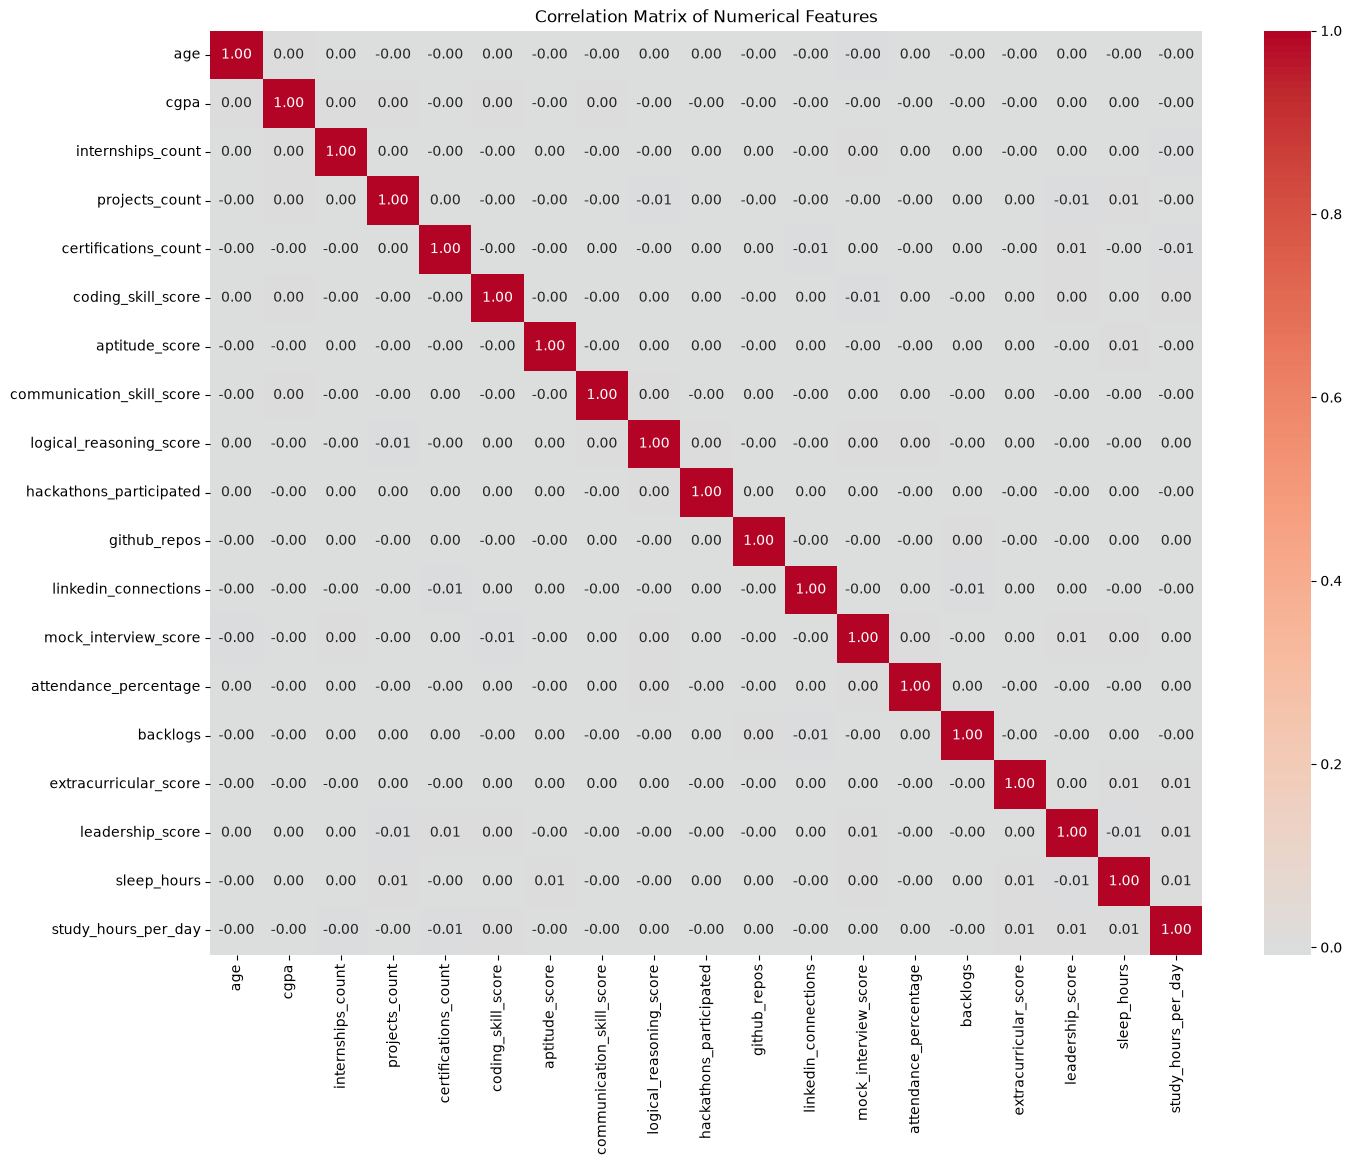

In [23]:
correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [24]:
df["placement_binary"] = (
    df["placement_status"] == "Placed"
).astype(int)

In [25]:
placement_correlations = (
    df[numeric_features + ["placement_binary"]]
    .corr()["placement_binary"]
    .sort_values(ascending=False)
)

placement_correlations

placement_binary             1.000000
internships_count            0.063489
projects_count               0.060964
coding_skill_score           0.050773
mock_interview_score         0.046058
logical_reasoning_score      0.036332
communication_skill_score    0.032242
aptitude_score               0.031690
leadership_score             0.022170
extracurricular_score        0.020100
cgpa                         0.012067
github_repos                 0.004807
linkedin_connections         0.003223
hackathons_participated      0.001236
age                          0.000858
study_hours_per_day         -0.001426
certifications_count        -0.003806
sleep_hours                 -0.004692
attendance_percentage       -0.008350
backlogs                    -0.082404
Name: placement_binary, dtype: float64

In [26]:
if "placement_binary" in df.columns:
    df.drop(columns=["placement_binary"], inplace=True)
    print("placement_binary removed.")
else:
    print("placement_binary is already absent. Nothing to remove.")

placement_binary removed.


In [27]:
print("placement_binary" in df.columns)

False


## Machine Learning Targets

This project contains two prediction tasks.

### Stage 1 — Placement Classification

The classification model predicts whether a student is placed.

Target:
`placement_status`

### Stage 2 — CTC Regression

The regression model predicts the salary package in LPA for students who are placed.

Target:
`salary_package_lpa`

The regression model is trained only using students whose historical placement status is `Placed`.

In [28]:
CLASSIFICATION_TARGET = "placement_status"
REGRESSION_TARGET = "salary_package_lpa"

print("Classification target:", CLASSIFICATION_TARGET)
print("Regression target:", REGRESSION_TARGET)

Classification target: placement_status
Regression target: salary_package_lpa


In [29]:
ID_COLUMN = "student_id"

print("Identifier excluded from modeling:", ID_COLUMN)

Identifier excluded from modeling: student_id


## Final Candidate Features

The following 23 student profile attributes are considered as model inputs.

The identifier and target columns are excluded from the feature set.

In [30]:
FEATURE_COLUMNS = [
    "age",
    "gender",
    "cgpa",
    "branch",
    "college_tier",
    "internships_count",
    "projects_count",
    "certifications_count",
    "coding_skill_score",
    "aptitude_score",
    "communication_skill_score",
    "logical_reasoning_score",
    "hackathons_participated",
    "github_repos",
    "linkedin_connections",
    "mock_interview_score",
    "attendance_percentage",
    "backlogs",
    "extracurricular_score",
    "leadership_score",
    "volunteer_experience",
    "sleep_hours",
    "study_hours_per_day"
]

print(f"Number of candidate features: {len(FEATURE_COLUMNS)}")

for feature in FEATURE_COLUMNS:
    print("-", feature)

Number of candidate features: 23
- age
- gender
- cgpa
- branch
- college_tier
- internships_count
- projects_count
- certifications_count
- coding_skill_score
- aptitude_score
- communication_skill_score
- logical_reasoning_score
- hackathons_participated
- github_repos
- linkedin_connections
- mock_interview_score
- attendance_percentage
- backlogs
- extracurricular_score
- leadership_score
- volunteer_experience
- sleep_hours
- study_hours_per_day


FORBIDDEN_COLUMNS = {
    "student_id",
    "placement_status",
    "salary_package_lpa"
}

leakage_columns = set(FEATURE_COLUMNS).intersection(FORBIDDEN_COLUMNS)

if leakage_columns:
    print("LEAKAGE DETECTED:")
    print(leakage_columns)
else:
    print("Leakage check passed.")

In [33]:
X_classification = df[FEATURE_COLUMNS].copy()
y_classification = df[CLASSIFICATION_TARGET].copy()

print("Classification feature shape:", X_classification.shape)
print("Classification target shape:", y_classification.shape)

Classification feature shape: (100000, 23)
Classification target shape: (100000,)


In [34]:
print(y_classification.value_counts())

placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64


In [35]:
placed_df = df[
    df[CLASSIFICATION_TARGET] == "Placed"
].copy()

X_regression = placed_df[FEATURE_COLUMNS].copy()
y_regression = placed_df[REGRESSION_TARGET].copy()

print("Placed students:", len(placed_df))
print("Regression feature shape:", X_regression.shape)
print("Regression target shape:", y_regression.shape)

Placed students: 54459
Regression feature shape: (54459, 23)
Regression target shape: (54459,)


In [36]:
print("Minimum CTC:", y_regression.min())
print("Maximum CTC:", y_regression.max())
print("Zero CTC records:", (y_regression == 0).sum())

Minimum CTC: 7.11
Maximum CTC: 20.44
Zero CTC records: 0


In [37]:
CATEGORICAL_FEATURES = [
    "gender",
    "branch",
    "college_tier",
    "volunteer_experience"
]

NUMERICAL_FEATURES = [
    feature
    for feature in FEATURE_COLUMNS
    if feature not in CATEGORICAL_FEATURES
]

print("Categorical features:", len(CATEGORICAL_FEATURES))
print("Numerical features:", len(NUMERICAL_FEATURES))

Categorical features: 4
Numerical features: 19


In [38]:
feature_ranges = df[FEATURE_COLUMNS].agg(["min", "max"]).T

feature_ranges

,min,max
age,18,24
gender,Female,Male
cgpa,4.5,10.0
branch,CSE,Mechanical
college_tier,Tier 1,Tier 3
internships_count,0,8
projects_count,0,13
certifications_count,0,11
coding_skill_score,20.0,100.0
aptitude_score,20.0,100.0
